In [1]:
import tensorflow as tf
from keras.datasets import mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 30s 3us/step  


In [2]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


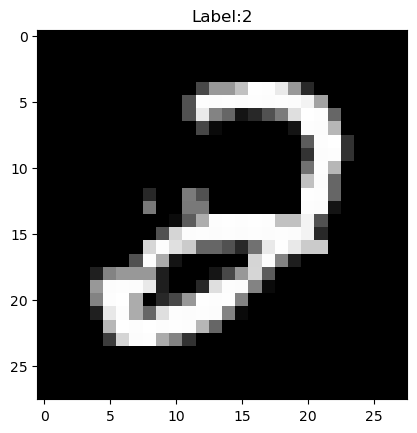

In [3]:
import matplotlib.pyplot as plt
plt.imshow(x_train[551],cmap="gray")
plt.title(f"Label:{y_train[551]}")
plt.show()

In [4]:
print(type(y_train))

<class 'numpy.ndarray'>


In [6]:
import pandas as pd
y_train_1=pd.DataFrame(y_train)
y_train_1.value_counts()

0
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

In [7]:
x_train=x_train.astype('float32')
x_test=x_test.astype('float32')
x_train=x_train/255
x_test=x_test/255
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [8]:
x_train=x_train.reshape(60000,28*28)
x_test=x_test.reshape(10000,28*28)
print(x_test.shape)
print(x_train.shape)

(10000, 784)
(60000, 784)


In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [10]:
model=Sequential()

In [18]:
# input layer + hidden layes
model.add(Dense(units=64,activation="relu",input_shape=(x_train.shape[1],)))
## hiden layer 2
model.add(Dense(units=10,activation="relu"))
## output layer
model.add(Dense(units=10,activation="softmax"))

In [19]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [20]:
hist=model.fit(x_train,y_train,epochs=50,verbose=1,validation_split=0.2,batch_size=32)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.3778 - loss: 1.5547 - val_accuracy: 0.5853 - val_loss: 1.0625
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6915 - loss: 0.9320 - val_accuracy: 0.7352 - val_loss: 0.8730
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7830 - loss: 0.7859 - val_accuracy: 0.7958 - val_loss: 0.7565
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8503 - loss: 0.6692 - val_accuracy: 0.8755 - val_loss: 0.6636
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8892 - loss: 0.5853 - val_accuracy: 0.8645 - val_loss: 0.6543
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9072 - loss: 0.5198 - val_accuracy: 0.9099 - val_loss: 0.5778
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9151 - loss: 0.4845 - val_accuracy: 0.9158 - val_loss: 0.5332
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9246 - loss: 0.42

In [22]:
acc=model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9038 - loss: 0.4402


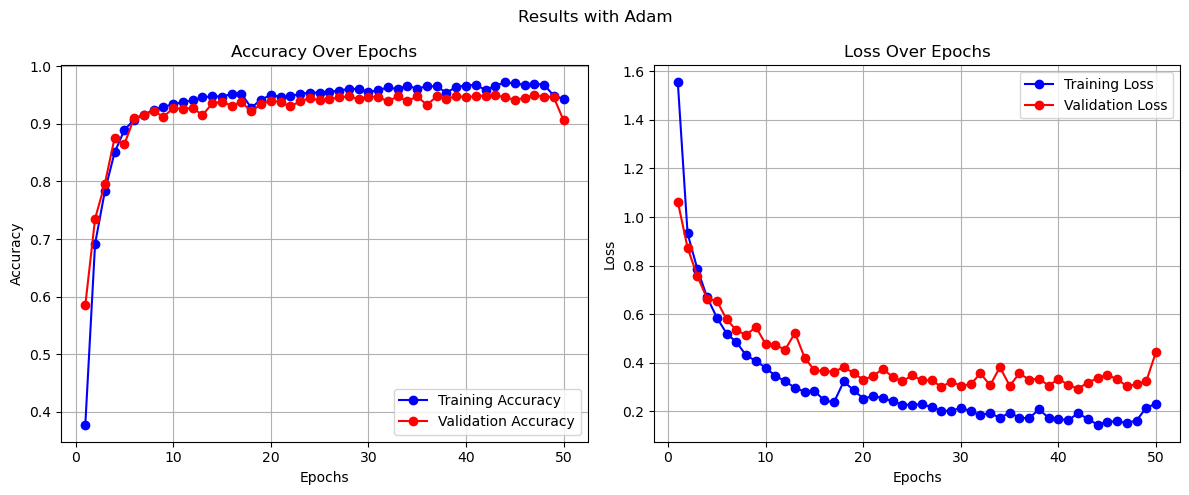

In [23]:
import matplotlib.pyplot as plt

# Extract metrics
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']

loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))
plt.suptitle("Results with Adam")

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()